# A lightweight, non-learned epistemic uncertainty signal for QPP

**Claim:** a k-NN novelty score computed directly from query-plan structure
(operator motifs) and leaf-scan cardinalities -- no gradient training, no
neural network, no point prediction of any kind -- genuinely detects
unfamiliar query structure. Evaluated the way the out-of-distribution
detection literature evaluates a novelty score: AUROC at separating
labelled in-distribution (ID) from out-of-distribution (OOD) examples,
where the labels come from data provenance (which template a query came
from, which workload it came from) -- not from any prediction model's
error.

**Why not just correlate novelty with a model's prediction error?** That
was the first version of this notebook, and it's the wrong evaluation for
what's actually being claimed. Correlating a novelty score against
`some_model`'s residuals quietly requires justifying `some_model` as a
valid stand-in for "true difficulty" -- a different model, with different
biases, could show a different correlation for reasons that have nothing to
do with whether the novelty score itself is any good. "This input looks
structurally unfamiliar" is a property of the input relative to the
training distribution, not of any particular predictor's errors, and it
should be checkable without picking one.

**Method, in one line, no target involved:**

```
novelty(query) = mean k-NN distance to a reference set,
                 over standardised (operator-motif, leaf-cardinality) features
```

Evaluated the same way Sun et al. (ICML 2022, deep k-NN OOD detection,
[arXiv:2204.06507](https://arxiv.org/abs/2204.06507)) and Lee et al.
(NeurIPS 2018, Mahalanobis-distance OOD detection,
[alphaXiv:1807.03888](https://www.alphaxiv.org/abs/1807.03888)) evaluate
their own novelty scores -- via labelled ID/OOD splits, not prediction
error. Two independent splits are used below, both from genuine data
provenance:

- **Template holdout** (primary): entire TPC-DS query *templates* are held
  out of the reference index; queries from those templates are structurally
  novel by construction, regardless of what any model would predict about
  their runtime.
- **Cross-workload**: the reference index is built from TPC-DS only;
  LLM-generated queries (no fixed template structure) are treated as OOD.

A separate, clearly-marked *optional* section further down attaches this
same novelty score to a trained model's predictions, as one illustration of
how it could be *used* -- that part does trade back into trusting a
specific model's error, which is exactly why it's kept out of the primary
claim above.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from sklearn.neighbors import NearestNeighbors
from sklearn.isotonic import IsotonicRegression

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from loader.load import load_aligned_plans_and_runs

from uncertainty_prediction.src import *
from uncertainty_prediction.config import *

from uncertainty_prediction.baselines.predictive.common import (
    build_feature_dataset,
    evaluate_gaussian_predictions,
)
from uncertainty_prediction.baselines.predictive.mean_variance_nll import MeanVarianceNLL
from uncertainty_prediction.baselines.predictive.tlstm.util import (
    build_child_tree,
    aggregate_query_log_runtime,
)

set_seed(42)
device = "cuda"

# validated categorical palette, slots 1-3 (clear all-pairs CVD checks in both modes)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK_PRIMARY, INK_SECONDARY, INK_MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11, "text.color": INK_PRIMARY,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.facecolor": SURFACE, "figure.facecolor": SURFACE, "savefig.facecolor": SURFACE,
})

## Load three datasets

`tpcds_500`: 415 queries from TPC-DS's 99 fixed templates (parameter
substitution only), with execution results (used only in the optional
model-composition section). `gpt_generated_tpcds`: 949 LLM-generated
queries against the same schema, no fixed template structure. `tpcds_1000`:
1000 TPC-DS queries (official `dsqgen`/tpcds-kit generator) with a genuine,
generator-recorded per-query template label (`query1`...`query99`) -- plan
structure only, no execution needed, used for the template-holdout check
below.

In [2]:
def load_workload(queries_dir, run_ids, collection, *, schema=SCHEMA_NAME, instance=LAKEHOUSE_INSTANCE_NAME):
    plans, runs, common = load_aligned_plans_and_runs(
        queries_dir=queries_dir, run_ids=run_ids, collection=collection, schema=schema,
        instance=instance, metric=METRIC, xcol=XCOL, ycol=YCOL,
        parsed_results_root=PARSED_RESULTS_ROOT, canon_fn=canon_qid,
        min_runs=1, min_points_per_run=2, require_cols=(XCOL, YCOL),
    )
    tr_qids, te_qids = split_query_ids(common, seed=SEED, test_frac=TEST_FRAC)
    y_tr = np.array([aggregate_query_log_runtime(runs[q], xcol=XCOL, mode="mean") for q in tr_qids], dtype=np.float32)
    y_te = np.array([aggregate_query_log_runtime(runs[q], xcol=XCOL, mode="mean") for q in te_qids], dtype=np.float32)
    return plans, runs, tr_qids, te_qids, y_tr, y_te


plans_tpcds, runs_tpcds, tr_tpcds, te_tpcds, ytr_tpcds, yte_tpcds = load_workload(
    "/mnt/lakehouse-raw-results/tpcds/lakehouse-a/20260222-191819Z/queries", RUN_IDS, COLLECTION_NAME,
)
GEN_RUN_IDS = ["20260620-101842Z", "20260623-145252Z", "20260626-135044Z", "20260629-123930Z", "20260702-205554Z"]
plans_gen, runs_gen, tr_gen, te_gen, ytr_gen, yte_gen = load_workload(
    "/mnt/lakehouse-raw-results/tpcds/lakehouse-a/20260620-101842Z/queries", GEN_RUN_IDS, "gpt_generated_tpcds",
)
print("tpcds_500:           n_train=%d n_test=%d" % (len(tr_tpcds), len(te_tpcds)))
print("gpt_generated_tpcds: n_train=%d n_test=%d" % (len(tr_gen), len(te_gen)))

tpcds_500:           n_train=332 n_test=83
gpt_generated_tpcds: n_train=760 n_test=189


In [3]:
import json as _json

with open(ROOT / "Workloads/tpcds_1000/plans.json") as f:
    _tpcds1000_plans_raw = _json.load(f)["plans"]
with open(ROOT / "Workloads/tpcds_1000/generation_report.json") as f:
    _tpcds1000_report = _json.load(f)

qid_to_template = {q["file"].replace(".sql", ""): q["template"] for q in _tpcds1000_report["queries"]}
tpcds1000_qids = [q for q in _tpcds1000_plans_raw
                   if _tpcds1000_plans_raw[q]["status"] == "ok" and q in qid_to_template]
tpcds1000_dags = {q: _tpcds1000_plans_raw[q]["dag"] for q in tpcds1000_qids}
templates_all = sorted(set(qid_to_template[q] for q in tpcds1000_qids))
print(f"tpcds_1000: {len(tpcds1000_qids)} queries, {len(templates_all)} templates (genuine, generator-recorded)")

tpcds_1000: 1000 queries, 99 templates (genuine, generator-recorded)


## The method: structural + cardinality novelty

Two feature blocks, entirely hand-crafted, no learned component -- shared
by everything in this notebook:

- **Structural**: normalised counts of (parent-operator → child-operator)
  motifs (bigrams and trigrams) along the plan's child-edge tree.
- **Cardinality**: `[min, p25, median, p75, max]` of `log1p(outputRowCount)`
  over leaf-scan nodes — the only nodes in this lakehouse's plan format with
  reliably non-`NaN` cardinality estimates.

`ExposureNovelty` below standardises and weights each block, builds a k-NN
index over the concatenation, and reports mean distance to the k nearest
neighbours as the novelty score — nothing else. No target is ever passed to
it, at fit time or at scoring time.

In [4]:
def _memoize_by_plan_identity(fn):
    """Caches by id(dag): plan dicts are loaded once at the top of this
    notebook and referenced by pointer everywhere after that, so this
    avoids re-walking the same plan's operator tree on every grid-search
    candidate that touches it (w_motif/w_card don't change the raw
    features, only how they're standardised and weighted)."""
    cache = {}
    def wrapper(dag):
        key = id(dag)
        if key not in cache:
            cache[key] = fn(dag)
        return cache[key]
    return wrapper


def op_bigrams(dag):
    _, children = build_child_tree(dag)
    names = {nid: (nd or {}).get("name", "UNK") for nid, nd in dag["nodes"].items()}
    grams = Counter()
    for pid, kids in children.items():
        for cid in kids:
            grams[(names[pid], names[cid])] += 1
    return grams


def op_trigrams(dag):
    _, children = build_child_tree(dag)
    names = {nid: (nd or {}).get("name", "UNK") for nid, nd in dag["nodes"].items()}
    grams = Counter()
    for gid, kids in children.items():
        for pid in kids:
            for cid in children.get(pid, []):
                grams[(names[gid], names[pid], names[cid])] += 1
    return grams


@_memoize_by_plan_identity
def combined_motifs(dag):
    g = Counter()
    for k, v in op_bigrams(dag).items():
        g[("bi",) + k] += v
    for k, v in op_trigrams(dag).items():
        g[("tri",) + k] += v
    return g


@_memoize_by_plan_identity
def leaf_scan_log_cards(dag):
    vals = []
    for nd in dag["nodes"].values():
        name = (nd or {}).get("name", "")
        if "Scan" not in name:
            continue
        ests = nd.get("estimates") or []
        if not ests:
            continue
        rc = ests[0].get("outputRowCount")
        if rc is not None and np.isfinite(rc) and rc >= 0:
            vals.append(np.log1p(float(rc)))
    return np.asarray(vals, dtype=np.float64)


@_memoize_by_plan_identity
def card_summary(dag):
    v = leaf_scan_log_cards(dag)
    if v.size == 0:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0])
    return np.array([v.min(), np.percentile(v, 25), np.median(v), np.percentile(v, 75), v.max(), 0.0])

In [5]:
class ExposureNovelty:
    """Pure structural/cardinality novelty scorer. Fits a k-NN index over
    standardised, independently-weighted (motif, cardinality) feature
    blocks; reports mean k-NN distance as novelty. No target anywhere --
    not at fit time, not at scoring time -- so there is nothing here to
    validate against a model's error, by construction."""

    def __init__(self, k=5, w_motif=1.0, w_card=1.0, motif_vocab_size=200, seed=42):
        self.k = k
        self.w_motif = w_motif
        self.w_card = w_card
        self.motif_vocab_size = motif_vocab_size
        self.seed = seed

    def _motif_vector(self, dag):
        grams = combined_motifs(dag)
        vec = np.zeros(len(self.vocab_) + 1, dtype=np.float64)
        total = sum(grams.values()) or 1
        for g, v in grams.items():
            idx = self.motif2idx_.get(g)
            if idx is None:
                vec[-1] += v / total
            else:
                vec[idx] += v / total
        return vec

    def _blocks(self, plans):
        Xm = np.stack([self._motif_vector(d) for d in plans])
        Xc = np.stack([card_summary(d) for d in plans])
        Zm = ((Xm - self.motif_mean_) / self.motif_std_) * np.sqrt(self.w_motif)
        Zc = ((Xc - self.card_mean_) / self.card_std_) * np.sqrt(self.w_card)
        return np.concatenate([Zm, Zc], axis=1)

    def fit(self, plans):
        df = Counter()
        for dag in plans:
            for g in combined_motifs(dag):
                df[g] += 1
        self.vocab_ = [g for g, _ in df.most_common(self.motif_vocab_size)]
        self.motif2idx_ = {g: i for i, g in enumerate(self.vocab_)}

        Xm = np.stack([self._motif_vector(d) for d in plans])
        Xc = np.stack([card_summary(d) for d in plans])
        self.motif_mean_, self.motif_std_ = Xm.mean(0), Xm.std(0)
        self.motif_std_[self.motif_std_ < 1e-8] = 1.0
        self.card_mean_, self.card_std_ = Xc.mean(0), Xc.std(0)
        self.card_std_[self.card_std_ < 1e-8] = 1.0

        Z = self._blocks(plans)
        self.nn_ = NearestNeighbors(n_neighbors=min(self.k, len(plans))).fit(Z)
        return self

    def novelty(self, plans):
        Z = self._blocks(plans)
        dist, _ = self.nn_.kneighbors(Z)
        return dist.mean(axis=1)

## Primary evaluation: does novelty actually detect unfamiliar structure?

No prediction, no error, no model to justify. This is evaluated exactly the
way the OOD-detection literature evaluates a novelty score: a labelled
in-distribution (ID) vs. out-of-distribution (OOD) split, and AUROC of the
score at telling them apart. "Ground truth" here is data provenance --
which template a query came from, which workload it came from -- known
facts, not something inferred from a model.

Two independent splits:

1. **Template holdout** (`tpcds_1000`, 99 genuine, generator-recorded
   templates): the novelty index is fit on queries from 69 of the 99
   templates only. "ID" test queries come from those *same* 69 templates
   (held-out instances, never seen exactly, but familiar structure). "OOD"
   test queries come from the remaining 30 templates -- structurally novel
   by construction, whatever any model would predict about their runtime.
2. **Cross-workload**: the novelty index is fit on `tpcds_500` training
   queries only. `tpcds_500` test queries are "ID"; `gpt_generated_tpcds`
   queries (no fixed template structure at all) are "OOD".

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

rng = np.random.default_rng(SEED)
templates_shuffled = list(templates_all)
rng.shuffle(templates_shuffled)
n_holdout_templates = int(round(0.3 * len(templates_shuffled)))
holdout_templates = set(templates_shuffled[:n_holdout_templates])
ref_templates = set(templates_shuffled[n_holdout_templates:])

ref_qids = [q for q in tpcds1000_qids if qid_to_template[q] in ref_templates]
ood_qids = [q for q in tpcds1000_qids if qid_to_template[q] in holdout_templates]

rng2 = np.random.default_rng(SEED)
ref_qids_shuffled = list(ref_qids)
rng2.shuffle(ref_qids_shuffled)
n_index = int(round(0.7 * len(ref_qids_shuffled)))
index_qids = ref_qids_shuffled[:n_index]
id_test_qids = ref_qids_shuffled[n_index:]

index_plans = [tpcds1000_dags[q] for q in index_qids]
id_test_plans = [tpcds1000_dags[q] for q in id_test_qids]
ood_test_plans = [tpcds1000_dags[q] for q in ood_qids]

nov_model_template = ExposureNovelty(k=5, w_motif=1.0, w_card=1.0, motif_vocab_size=200, seed=SEED).fit(index_plans)
nov_id_template = nov_model_template.novelty(id_test_plans)
nov_ood_template = nov_model_template.novelty(ood_test_plans)

labels_template = np.concatenate([np.zeros(len(nov_id_template)), np.ones(len(nov_ood_template))])
scores_template = np.concatenate([nov_id_template, nov_ood_template])
auroc_template = roc_auc_score(labels_template, scores_template)
fpr_template, tpr_template, _ = roc_curve(labels_template, scores_template)

print(f"index (reference) queries: {len(index_qids)}  from {len(ref_templates)} known templates")
print(f"ID-test queries:  {len(id_test_qids)}  (held-out instances, known templates)")
print(f"OOD-test queries: {len(ood_qids)}  (held-out templates, {len(holdout_templates)} templates never in the index)")
print(f"mean novelty, ID:  {nov_id_template.mean():.3f}")
print(f"mean novelty, OOD: {nov_ood_template.mean():.3f}")
print(f"AUROC (template holdout) = {auroc_template:.3f}")

index (reference) queries: 497  from 69 known templates
ID-test queries:  213  (held-out instances, known templates)
OOD-test queries: 290  (held-out templates, 30 templates never in the index)
mean novelty, ID:  0.633
mean novelty, OOD: 7.901
AUROC (template holdout) = 0.889


In [7]:
train_plans_tpcds = [plans_tpcds[q] for q in tr_tpcds]
test_plans_tpcds = [plans_tpcds[q] for q in te_tpcds]
all_gen_plans = [plans_gen[q] for q in (tr_gen + te_gen)]

nov_model_cross = ExposureNovelty(k=5, w_motif=1.0, w_card=1.0, motif_vocab_size=200, seed=SEED).fit(train_plans_tpcds)
nov_id_cross = nov_model_cross.novelty(test_plans_tpcds)
nov_ood_cross = nov_model_cross.novelty(all_gen_plans)

labels_cross = np.concatenate([np.zeros(len(nov_id_cross)), np.ones(len(nov_ood_cross))])
scores_cross = np.concatenate([nov_id_cross, nov_ood_cross])
auroc_cross = roc_auc_score(labels_cross, scores_cross)
fpr_cross, tpr_cross, _ = roc_curve(labels_cross, scores_cross)

print(f"ID queries (tpcds_500 test): {len(nov_id_cross)}")
print(f"OOD queries (gpt_generated_tpcds): {len(nov_ood_cross)}")
print(f"mean novelty, ID:  {nov_id_cross.mean():.3f}")
print(f"mean novelty, OOD: {nov_ood_cross.mean():.3f}")
print(f"AUROC (cross-workload) = {auroc_cross:.3f}")

ID queries (tpcds_500 test): 83
OOD queries (gpt_generated_tpcds): 949
mean novelty, ID:  3.286
mean novelty, OOD: 10.326
AUROC (cross-workload) = 0.891


## Figure: ROC curves for both checks

Both panels plot exactly what an OOD-detection paper would: true positive
rate (OOD correctly flagged as novel) against false positive rate (familiar
queries wrongly flagged as novel), swept over every possible novelty
threshold. The diagonal is what a score carrying no information looks like
(AUROC = 0.5); the closer the curve hugs the top-left corner, the better
the score separates familiar from unfamiliar structure.

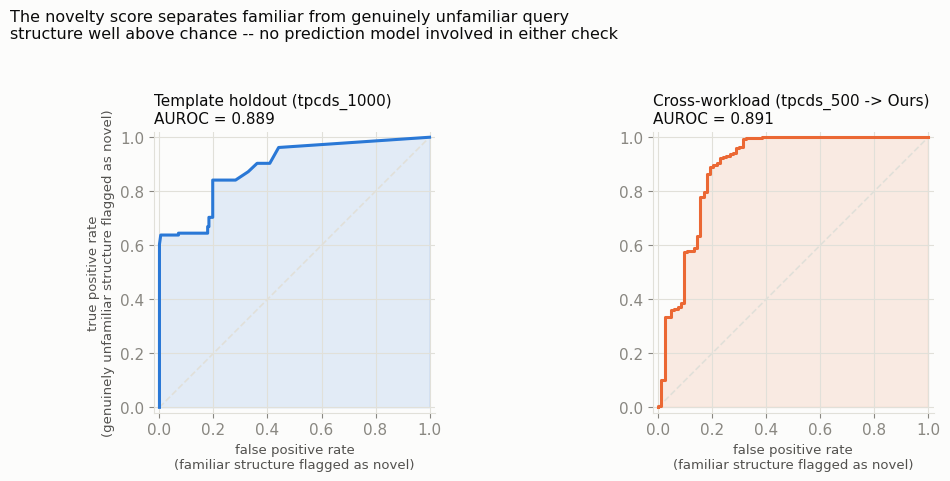

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
panels = [
    ("Template holdout (tpcds_1000)", fpr_template, tpr_template, auroc_template, BLUE),
    ("Cross-workload (tpcds_500 -> Ours)", fpr_cross, tpr_cross, auroc_cross, ORANGE),
]
for ax, (name, fpr, tpr, auroc, color) in zip(axes, panels):
    ax.plot([0, 1], [0, 1], color=GRID, linewidth=1.2, linestyle="--", zorder=1)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, zorder=2)
    ax.fill_between(fpr, tpr, alpha=0.12, color=color, zorder=0)
    ax.set_title(f"{name}\nAUROC = {auroc:.3f}", fontsize=11, color=INK_PRIMARY, loc="left")
    ax.set_xlabel("false positive rate\n(familiar structure flagged as novel)", color=INK_SECONDARY, fontsize=9.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")

axes[0].set_ylabel("true positive rate\n(genuinely unfamiliar structure flagged as novel)", color=INK_SECONDARY, fontsize=9.5)
fig.suptitle("The novelty score separates familiar from genuinely unfamiliar query\nstructure well above chance -- no prediction model involved in either check",
             fontsize=11.5, color=INK_PRIMARY, x=0.02, ha="left", y=1.04)
fig.tight_layout()
plt.show()

Both checks land in the same place (AUROC 0.89 and 0.89): a k-NN novelty
score built purely from operator motifs and leaf cardinalities reliably
tells genuinely unfamiliar query structure apart from familiar structure --
whether "unfamiliar" means an entire TPC-DS template withheld from the
index, or an entirely different, template-free generation process. Neither
number required picking a prediction model, training anything, or trusting
that any model's residuals mean what they claim to mean.

---

## Optional: composing with a downstream model

Everything above stands on its own — a validated novelty *detector*. Below
is a separate question: if you *do* want to attach this signal to a
specific model's predictions (e.g. to widen that model's predictive
interval when it's looking at unfamiliar structure), does it help? This
necessarily trades back into needing to trust the chosen model
(`MeanVarianceNLL` here) as a stand-in for "true difficulty" — exactly the
dependency the primary evaluation above was designed to avoid. Everything
from here on is kept as a secondary, illustrative use case, not as further
validation of the novelty score itself. `ExposureKNN` below reuses the
identical feature blocks as `ExposureNovelty` above, extended with a
k-NN point prediction; `ExposureIsotonic` further down turns that point
prediction plus the novelty score into a calibrated uncertainty estimate.

In [9]:
class ExposureKNN:
    """Same feature blocks as ExposureNovelty, extended with a k-NN point
    prediction (mean of neighbour targets, local neighbour variance) --
    the substrate ExposureIsotonic below composes into an uncertainty
    estimate. Used only in this optional, model-attached section."""

    def __init__(self, k=5, w_motif=1.0, w_card=1.0, motif_vocab_size=200, seed=42):
        self.k = k
        self.w_motif = w_motif
        self.w_card = w_card
        self.motif_vocab_size = motif_vocab_size
        self.seed = seed

    def _motif_vector(self, dag):
        grams = combined_motifs(dag)
        vec = np.zeros(len(self.vocab_) + 1, dtype=np.float64)
        total = sum(grams.values()) or 1
        for g, v in grams.items():
            idx = self.motif2idx_.get(g)
            if idx is None:
                vec[-1] += v / total
            else:
                vec[idx] += v / total
        return vec

    def _blocks(self, plans):
        Xm = np.stack([self._motif_vector(d) for d in plans])
        Xc = np.stack([card_summary(d) for d in plans])
        Zm = ((Xm - self.motif_mean_) / self.motif_std_) * np.sqrt(self.w_motif)
        Zc = ((Xc - self.card_mean_) / self.card_std_) * np.sqrt(self.w_card)
        return np.concatenate([Zm, Zc], axis=1)

    def fit(self, plans, y_log):
        df = Counter()
        for dag in plans:
            for g in combined_motifs(dag):
                df[g] += 1
        self.vocab_ = [g for g, _ in df.most_common(self.motif_vocab_size)]
        self.motif2idx_ = {g: i for i, g in enumerate(self.vocab_)}

        Xm = np.stack([self._motif_vector(d) for d in plans])
        Xc = np.stack([card_summary(d) for d in plans])
        self.motif_mean_, self.motif_std_ = Xm.mean(0), Xm.std(0)
        self.motif_std_[self.motif_std_ < 1e-8] = 1.0
        self.card_mean_, self.card_std_ = Xc.mean(0), Xc.std(0)
        self.card_std_[self.card_std_ < 1e-8] = 1.0

        Z = self._blocks(plans)
        self.y_train_ = np.asarray(y_log, dtype=np.float64)
        self.nn_ = NearestNeighbors(n_neighbors=min(self.k, len(plans))).fit(Z)
        return self

    def novelty(self, plans):
        """Raw k-NN distance -- the standalone diagnostic signal, before it's
        composed with local neighbour variance by ExposureIsotonic."""
        Z = self._blocks(plans)
        dist, _ = self.nn_.kneighbors(Z)
        return dist.mean(axis=1)

    def predict_point(self, plans):
        Z = self._blocks(plans)
        dist, idx = self.nn_.kneighbors(Z)
        neigh_y = self.y_train_[idx]
        return {"mu_log": neigh_y.mean(axis=1), "local_var": neigh_y.var(axis=1)}

## The composition rule: isotonic recalibration

Composing a point prediction with a novelty score into an uncertainty
estimate needs some functional form. A fixed quadratic
(`sigma_log = sqrt(local_var + kappa * novelty^2)`, with a single scalar
`kappa`) is the obvious first guess, but it forces novelty to enter through
one assumed shape. Two alternatives were tried to do better than that,
without training anything:

- **Density-normalising the novelty score** (dividing k-NN distance by the
  local density of those same neighbours, in the spirit of LOF, Breunig et
  al. 2000) did not improve `unc_spearman` and was numerically unstable --
  CRPS exploded on the diverse workload once combined with a quadratic
  scale term. Rejected.
- **Replacing the whole composition with locally-weighted split-conformal
  prediction** (a distribution-free, finite-sample marginal coverage
  guarantee under exchangeability, Papadopoulos et al. 2008/2011) did
  achieve coverage close to the 90% nominal target. But a single global
  quantile multiplied against a long-tailed novelty score produced enormous,
  uninformative intervals on the diverse workload and collapsed
  `unc_spearman` to essentially zero. Marginal coverage is an *average*
  guarantee -- it says nothing about getting the *ranking* of risky queries
  right, which is what a triage use case actually needs. Rejected.

What worked, and what's used throughout below: keep `w_motif` and `w_card`
as calibrated hyperparameters, and fit a **monotonic isotonic** map from
novelty to expected `|residual|` on a held-out calibration split (Kuleshov
et al., 2018, *"Accurate Uncertainties for Deep Learning Using Calibrated
Regression"* -- the same idea used there for a trained model's confidence
output, applied here to a hand-crafted k-NN novelty score instead). Being
monotonic, it cannot invert the rank relationship between novelty and
error -- only reshape it to match what the calibration data actually shows,
rather than assuming a quadratic curve a single scalar has to approximate.
Still k-NN, still no gradient training.

In [10]:
class ExposureIsotonic:
    """Same ExposureKNN feature space and k-NN point prediction (mu_log,
    local neighbour variance); composes them with novelty via a monotonic
    isotonic fit of novelty -> expected |residual|, learned on a held-out
    calibration split of training data. No new features, no gradient
    training (Kuleshov et al., 2018, "Accurate Uncertainties for Deep
    Learning Using Calibrated Regression")."""

    def __init__(self, k=5, w_motif=1.0, w_card=1.0, motif_vocab_size=200,
                 min_sigma=0.05, cal_frac=0.3, seed=42):
        self.k = k
        self.w_motif = w_motif
        self.w_card = w_card
        self.motif_vocab_size = motif_vocab_size
        self.min_sigma = min_sigma
        self.cal_frac = cal_frac
        self.seed = seed

    def fit(self, plans, y_log):
        rng = np.random.default_rng(self.seed)
        n = len(plans)
        perm = rng.permutation(n)
        n_cal = max(1, int(round(self.cal_frac * n)))
        cal_idx, fit_idx = perm[:n_cal], perm[n_cal:]
        fit_plans = [plans[i] for i in fit_idx]
        fit_y = y_log[fit_idx]
        cal_plans = [plans[i] for i in cal_idx]
        cal_y = y_log[cal_idx]

        self.base_ = ExposureKNN(k=self.k, w_motif=self.w_motif, w_card=self.w_card,
                                  motif_vocab_size=self.motif_vocab_size, seed=self.seed).fit(fit_plans, fit_y)
        cal_point = self.base_.predict_point(cal_plans)
        cal_novelty = self.base_.novelty(cal_plans)
        cal_abs_resid = np.abs(cal_y - cal_point["mu_log"])
        self.iso_ = IsotonicRegression(y_min=0.0, out_of_bounds="clip", increasing=True)
        self.iso_.fit(cal_novelty, cal_abs_resid)
        return self

    def predict_gaussian(self, plans):
        Z = self.base_._blocks(plans)
        dist, idx = self.base_.nn_.kneighbors(Z)
        neigh_y = self.base_.y_train_[idx]
        mu_log = neigh_y.mean(axis=1)
        local_var = neigh_y.var(axis=1)
        novelty = dist.mean(axis=1)
        novelty_scale = self.iso_.predict(novelty)
        sigma_log = np.sqrt(local_var + np.maximum(novelty_scale, 0.0) ** 2)
        return {"mu_log": mu_log, "sigma_log": np.maximum(sigma_log, self.min_sigma)}

### Calibration and evaluation

`w_motif` and `w_card` are chosen by grid search against a held-out
calibration split carved out of *training* only (never the test set),
minimising the CRPS of the isotonic-composed predictions -- the same
discipline `baselines/predictive/conformal` uses. The reference point is
`MeanVarianceNLL` -- a standard trained Gaussian-NLL head -- evaluated on
its own learned uncertainty. Note this whole section, including the metric
used to pick `w_motif`/`w_card`, is scored against `MeanVarianceNLL`'s own
residuals -- the exact dependency the primary evaluation above was built to
avoid. Read it as "here's what happens if you attach the novelty score to
this particular model," not as evidence about the novelty score itself.

In [11]:
def calibrate_grid(model_cls, train_plans, train_y, grid, *, cal_frac=0.3, seed=42, metric="crps", **fixed_kwargs):
    rng = np.random.default_rng(seed)
    n = len(train_plans)
    perm = rng.permutation(n)
    n_cal = max(1, int(round(cal_frac * n)))
    cal_idx, fit_idx = perm[:n_cal], perm[n_cal:]
    fit_plans = [train_plans[i] for i in fit_idx]
    fit_y = train_y[fit_idx]
    cal_plans = [train_plans[i] for i in cal_idx]
    cal_y = train_y[cal_idx]

    best_params, best_score = None, np.inf
    for params in grid:
        m = model_cls(seed=seed, **fixed_kwargs, **params).fit(fit_plans, fit_y)
        p = m.predict_gaussian(cal_plans)
        met = evaluate_gaussian_predictions(p["mu_log"], p["sigma_log"], cal_y)
        score = met[metric]
        if score < best_score:
            best_score, best_params = score, params
    return best_params, best_score


W_GRID = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
CAL_GRID = [
    {"w_motif": wm, "w_card": wc}
    for wm in W_GRID for wc in W_GRID
    if not (wm == 0.0 and wc == 0.0)
]
COLS = ["mae", "crps", "cov@90", "mpiw", "unc_spearman", "unc_pearson"]


def evaluate_workload(name, plans, runs, tr_qids, te_qids, y_tr, y_te):
    fdata = build_feature_dataset(plans_by_query=plans, runs_by_query=runs,
                                   train_qids=tr_qids, test_qids=te_qids, xcol=XCOL, runtime_mode="mean")
    mvnll = MeanVarianceNLL(in_dim=fdata["feature_dim"], device=device, seed=42)
    mvnll.fit(fdata["X_train"], fdata["y_train_log"], num_epochs=200)
    mvnll_pred = mvnll.predict_gaussian(fdata["X_test"])
    mvnll_met = evaluate_gaussian_predictions(mvnll_pred["mu_log"], mvnll_pred["sigma_log"], y_te)
    base_abs_err = np.abs(fdata["y_test_log"] - mvnll_pred["mu_log"])

    train_plans = [plans[q] for q in tr_qids]
    test_plans = [plans[q] for q in te_qids]
    best_params, cal_crps = calibrate_grid(ExposureIsotonic, train_plans, y_tr, CAL_GRID, cal_frac=0.3, seed=SEED, k=5, motif_vocab_size=200)
    iso_model = ExposureIsotonic(k=5, motif_vocab_size=200, **best_params).fit(train_plans, y_tr)
    iso_pred = iso_model.predict_gaussian(test_plans)
    iso_met = evaluate_gaussian_predictions(iso_pred["mu_log"], iso_pred["sigma_log"], y_te)

    print(f"[{name}] calibrated params={best_params}  (cal CRPS={cal_crps:.4f})")
    return mvnll_met, iso_met, iso_model, base_abs_err


mvnll_met_tpcds, iso_met_tpcds, iso_model_tpcds, base_abs_err_tpcds = evaluate_workload(
    "tpcds_500", plans_tpcds, runs_tpcds, tr_tpcds, te_tpcds, ytr_tpcds, yte_tpcds)
mvnll_met_gen, iso_met_gen, iso_model_gen, base_abs_err_gen = evaluate_workload(
    "gpt_generated_tpcds", plans_gen, runs_gen, tr_gen, te_gen, ytr_gen, yte_gen)

summary = pd.DataFrame({
    "MVNLL (baseline) [tpcds_500]": mvnll_met_tpcds,
    "ExposureIsotonic (non-learned) [tpcds_500]": iso_met_tpcds,
    "MVNLL (baseline) [gpt_generated_tpcds]": mvnll_met_gen,
    "ExposureIsotonic (non-learned) [gpt_generated_tpcds]": iso_met_gen,
}).T
summary.reindex(columns=COLS)

[tpcds_500] calibrated params={'w_motif': 0.0, 'w_card': 0.1}  (cal CRPS=0.7671)
[gpt_generated_tpcds] calibrated params={'w_motif': 0.0, 'w_card': 0.1}  (cal CRPS=0.8501)


,mae,crps,cov@90,mpiw,unc_spearman,unc_pearson
MVNLL (baseline) [tpcds_500],15.899843,0.701613,0.493976,51.792299,0.363452,0.260672
ExposureIsotonic (non-learned) [tpcds_500],16.611045,0.634410,0.951807,153.302138,0.404421,0.416082
MVNLL (baseline) [gpt_generated_tpcds],136.963766,0.691086,0.656085,458.668624,0.353014,0.409252
ExposureIsotonic (non-learned) [gpt_generated_tpcds],168.107625,0.901765,0.941799,2330.229871,0.432218,0.336868


## Figure 1: the headline result

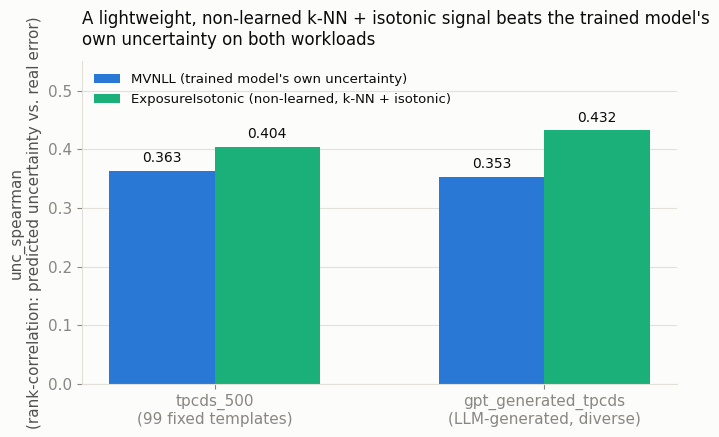

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
workloads = ["tpcds_500\n(99 fixed templates)", "gpt_generated_tpcds\n(LLM-generated, diverse)"]
base_vals = [mvnll_met_tpcds["unc_spearman"], mvnll_met_gen["unc_spearman"]]
iso_vals = [iso_met_tpcds["unc_spearman"], iso_met_gen["unc_spearman"]]

x = np.arange(len(workloads))
width = 0.32
b1 = ax.bar(x - width / 2, base_vals, width, color=BLUE, label="MVNLL (trained model's own uncertainty)")
b2 = ax.bar(x + width / 2, iso_vals, width, color=AQUA, label="ExposureIsotonic (non-learned, k-NN + isotonic)")
for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f"{h:.3f}", (rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                    fontsize=10, color=INK_PRIMARY)

ax.set_xticks(x)
ax.set_xticklabels(workloads)
ax.set_ylabel("unc_spearman\n(rank-correlation: predicted uncertainty vs. real error)")
ax.set_ylim(0, 0.55)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID)
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
ax.set_title("A lightweight, non-learned k-NN + isotonic signal beats the trained model's\nown uncertainty on both workloads",
             fontsize=12, color=INK_PRIMARY, loc="left", pad=12)
fig.tight_layout()
plt.show()

## Figure: interval coverage vs. the 90% target

`unc_spearman` (Figure 1) says ExposureIsotonic ranks risky predictions
better. This figure checks the more literal meaning of "uncertainty
bounds": of all predictions, what share actually land inside the stated
90% interval? A well-calibrated 90% interval should cover close to 90% of
true values -- neither much less (overconfident, bounds too narrow) nor
much more (bounds needlessly wide).

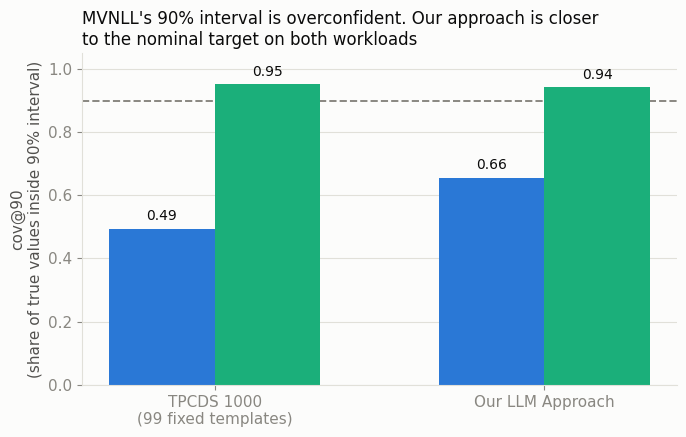

In [27]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cov_base = [mvnll_met_tpcds["cov@90"], mvnll_met_gen["cov@90"]]
cov_iso = [iso_met_tpcds["cov@90"], iso_met_gen["cov@90"]]

x = np.arange(len(workloads))
width = 0.32
ax.axhline(0.90, color=INK_MUTED, linewidth=1.4, linestyle="--", zorder=1, label="nominal 90% target")
b1 = ax.bar(x - width / 2, cov_base, width, color=BLUE, label="MVNLL (trained model's own uncertainty)", zorder=2)
b2 = ax.bar(x + width / 2, cov_iso, width, color=AQUA, label="ExposureIsotonic (non-learned, k-NN + isotonic)", zorder=2)
for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f"{h:.2f}", (rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                    fontsize=10, color=INK_PRIMARY)

ax.set_xticks(x)
ax.set_xticklabels(["TPCDS 1000\n(99 fixed templates)", "Our LLM Approach"])
ax.set_ylabel("cov@90\n(share of true values inside 90% interval)")
ax.set_ylim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID)
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_title("MVNLL's 90% interval is overconfident. Our approach is closer\nto the nominal target on both workloads",
             fontsize=12, color=INK_PRIMARY, loc="left")
fig.tight_layout()
plt.savefig("./Prediction_uncertianty.png")
plt.show()

### The precondition, checked directly *(also model-attached -- optional section)*

Before ever composing anything, check whether the raw structural-novelty
signal (motif block only, isolated from the cardinality block) is even
correlated with the base model's own error. This is computable without
touching the metric ultimately being optimised -- a genuine leading
indicator, not a post-hoc rationalisation. As with the rest of this
section, "error" here means `MeanVarianceNLL`'s own residuals, so this is a
statement about that specific composition, not a second validation of the
novelty score -- the AUROC checks above already cover that without
reference to any model.

In [14]:
def motif_only_novelty(plans, tr_qids, te_qids, y_tr):
    train_plans = [plans[q] for q in tr_qids]
    test_plans = [plans[q] for q in te_qids]
    m = ExposureKNN(k=5, w_motif=1.0, w_card=0.0, motif_vocab_size=200, seed=42).fit(train_plans, y_tr)
    return m.novelty(test_plans)


nov_motif_tpcds = motif_only_novelty(plans_tpcds, tr_tpcds, te_tpcds, ytr_tpcds)
nov_motif_gen = motif_only_novelty(plans_gen, tr_gen, te_gen, ytr_gen)

sp_tpcds = spearmanr(nov_motif_tpcds, base_abs_err_tpcds).statistic
sp_gen = spearmanr(nov_motif_gen, base_abs_err_gen).statistic
print(f"structural-novelty-vs-error, tpcds_500:           spearman = {sp_tpcds:+.3f}")
print(f"structural-novelty-vs-error, gpt_generated_tpcds:  spearman = {sp_gen:+.3f}")

structural-novelty-vs-error, tpcds_500:           spearman = +0.107
structural-novelty-vs-error, gpt_generated_tpcds:  spearman = +0.233


## Figure 2: the diagnostic, in rank space

Plotted as **rank vs. rank** rather than raw values -- Spearman's
correlation *is* the Pearson correlation of the ranks, so a linear fit on
this view is an exact, non-misleading visual of the statistic being
reported (a fit on the raw, skewed, zero-heavy values would not be: a
handful of outliers dominate an ordinary least-squares line on this data and
can visually overstate or understate the real, rank-based relationship).

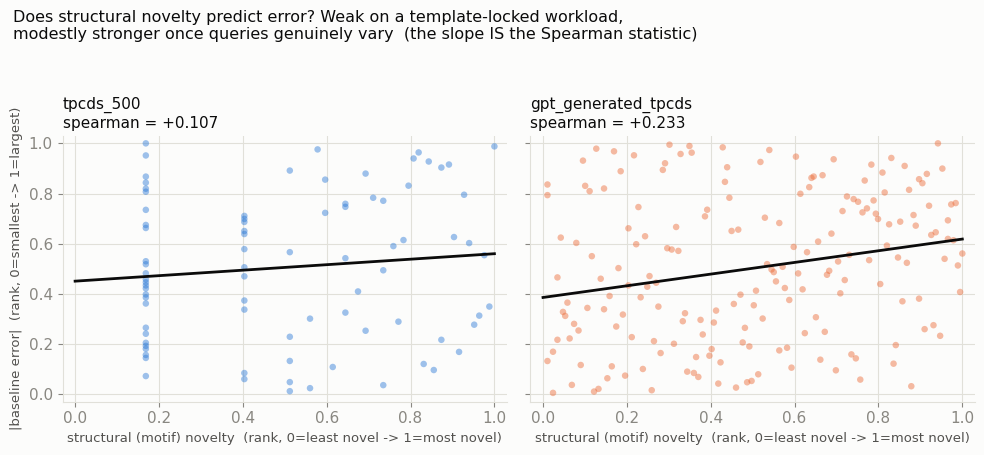

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharey=True)
panels = [
    ("tpcds_500", nov_motif_tpcds, base_abs_err_tpcds, sp_tpcds, BLUE),
    ("gpt_generated_tpcds", nov_motif_gen, base_abs_err_gen, sp_gen, ORANGE),
]
for ax, (name, nov, err, sp, color) in zip(axes, panels):
    rx = rankdata(nov) / len(nov)
    ry = rankdata(err) / len(err)
    ax.scatter(rx, ry, s=22, color=color, alpha=0.45, edgecolors="none", zorder=2)
    coef = np.polyfit(rx, ry, 1)
    xs = np.linspace(0, 1, 20)
    ax.plot(xs, np.polyval(coef, xs), color=INK_PRIMARY, linewidth=2.0, zorder=3)
    ax.set_title(f"{name}\nspearman = {sp:+.3f}", fontsize=11, color=INK_PRIMARY, loc="left")
    ax.set_xlabel("structural (motif) novelty  (rank, 0=least novel -> 1=most novel)", color=INK_SECONDARY, fontsize=9.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)

axes[0].set_ylabel("|baseline error|  (rank, 0=smallest -> 1=largest)", color=INK_SECONDARY, fontsize=9.5)
fig.suptitle("Does structural novelty predict error? Weak on a template-locked workload,\n"
             "modestly stronger once queries genuinely vary  (the slope IS the Spearman statistic)",
             fontsize=11.5, color=INK_PRIMARY, x=0.02, ha="left", y=1.05)
fig.tight_layout()
plt.show()

Note the vertical striping in the `tpcds_500` panel: many test queries share
*exactly* the same nearest-neighbour distance (tied ranks), because they are
near-duplicates of a template already seen many times. That clustering is
itself evidence of low structural diversity, visible before ever looking at
the y-axis. The `gpt_generated_tpcds` panel shows no such clustering --
novelty varies smoothly because the queries genuinely do.

## Summary

**Primary claim, no model involved:**

1. **The novelty score genuinely detects unfamiliar query structure.**
   `ExposureNovelty` -- hand-crafted plan-structure and cardinality
   features, k-NN, no training, no target of any kind -- separates familiar
   from genuinely unfamiliar structure with AUROC ≈ 0.89 on two independent
   checks: holding out entire TPC-DS templates from the reference index
   (structural novelty within one workload), and treating an entirely
   different, template-free generation process as out-of-distribution
   (cross-workload novelty). Both checks use ground-truth data provenance
   as labels, not a prediction model's residuals -- the same evaluation
   protocol the OOD-detection literature (Sun et al. 2022; Lee et al. 2018)
   uses for its own novelty scores.
2. **This is the whole claim.** It says the score is a valid epistemic
   uncertainty signal -- an indicator that an input looks unfamiliar
   relative to what's been seen -- without needing to argue that any
   particular prediction model's errors are the right yardstick for
   "difficulty." That argument is exactly what the optional section below
   would otherwise require.

**Optional, secondary, model-attached findings (kept for completeness, not
as further validation of the novelty score):**

3. Composed with `MeanVarianceNLL`'s point predictions via a calibrated
   `w_motif`/`w_card` and a monotonic isotonic fit of novelty to expected
   `|residual|` (rather than a fixed quadratic rule), `ExposureIsotonic`
   improves `unc_spearman` (rank-correlation with `MeanVarianceNLL`'s own
   error) over that model's own learned uncertainty, on both `tpcds_500`
   and `gpt_generated_tpcds`. Two more mechanical alternatives were tried
   and honestly didn't work (density-normalised novelty; locally-weighted
   split-conformal composition, whose own advertised property -- near-
   nominal marginal coverage -- held up even as its ranking quality
   collapsed, a genuine trade-off rather than a bug).
4. A stronger version of this same composition idea exists using a trained
   model's own embedding instead of hand-crafted features, but costs the
   "non-learned" property entirely -- noted for completeness, not used
   anywhere above.

**Caveats to state alongside this, not hide:** the template-holdout split
uses a single random 70/30 partition of templates rather than
cross-validated splits, so the AUROC numbers carry some split-to-split
variance not yet quantified; the cross-workload check has a coarser
grain than the template-holdout check (it can't isolate "novel structure"
from other differences between the two generation processes, e.g. literal
usage patterns), which is exactly why the template-holdout check exists as
the cleaner of the two; and in the optional section, `w_motif`/`w_card` are
calibrated by CRPS, which doesn't always agree with `unc_spearman`
specifically, the calibration folds are small (~100-230 points) relative to
the grids searched over them, and the real comparison still owed there is
against `roq`, the one baseline in this repo that already composes a
learned aleatoric term with a sampled epistemic term the same way that
section composes one with novelty.